![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
# Prevención de alertas
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor, export_graphviz, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

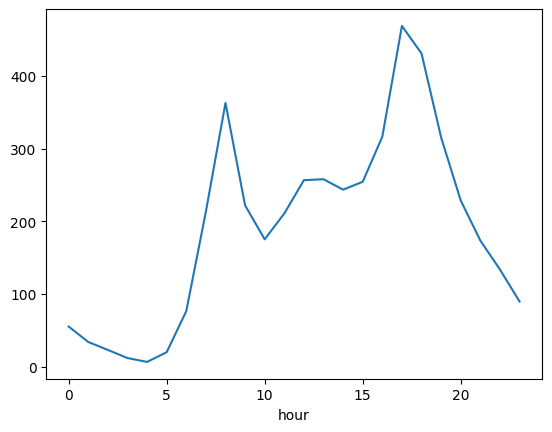

In [6]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

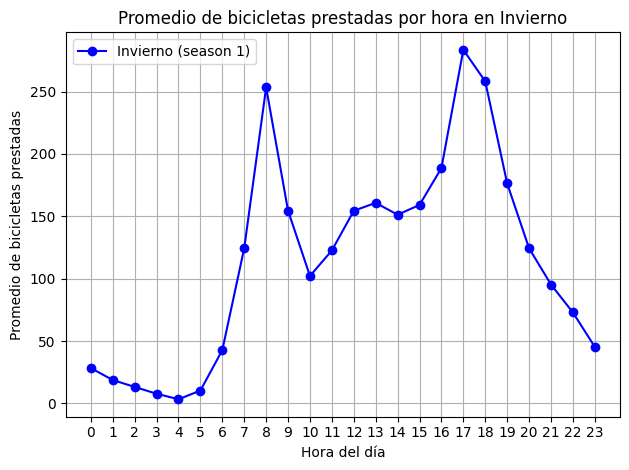

In [7]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
season_1 = bikes[bikes['season'] == 1].dropna(subset=['total']).groupby('hour')['total'].mean()
plt.plot(season_1.index, season_1.values, label='Invierno (season 1)', color='blue', marker='o')

# Estilos visuales
plt.title('Promedio de bicicletas prestadas por hora en Invierno')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de bicicletas prestadas')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### Comportamiento del renting de bicicletas durante la temporda de invierno
En términos generales se puede considerar que se mantiene la tendencia de rentas a lo largo del día, presentando los mismos intervalos de horas pico y valle. Sin embargo, se evidencia que durante la temporada de invierno el renting de bicicletas es considerablemente menor al valor promedio general, presentando un valor máximo por el orden de 280, mientras el valor de referencia está encima de 450.

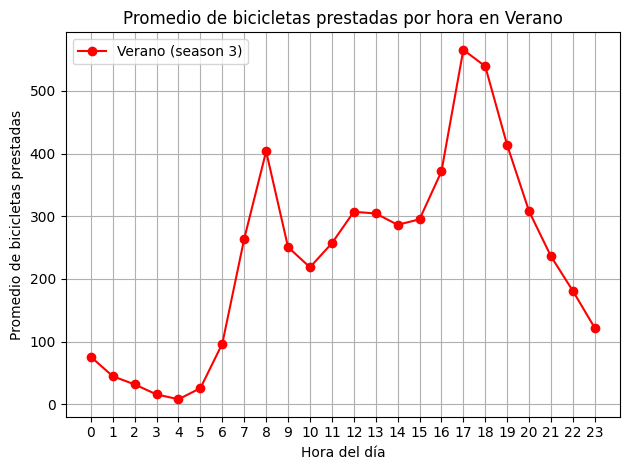

In [8]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
season_1 = bikes[bikes['season'] == 3].dropna(subset=['total']).groupby('hour')['total'].mean()
plt.plot(season_1.index, season_1.values, label='Verano (season 3)', color='red', marker='o')

# Estilos visuales
plt.title('Promedio de bicicletas prestadas por hora en Verano')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de bicicletas prestadas')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### Comportamiento del renting de bicicletas durante la temporda de verano
En términos generales se puede considerar que se mantiene la tendencia de rentas a lo largo del día, presentando los mismos intervalos de horas pico y valle. Sin embargo, se evidencia que durante la temporada de verano el renting de bicicletas es considerablemente mayor al valor promedio general, superando el valor referencia máximo de 450.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [9]:
# Celda 3

# Selección de variables predictoras y variable objetivo
X = bikes[['season', 'hour']].copy()
X = pd.get_dummies(X, columns=['season'])
y = bikes['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo de regresión lineal
lr = LinearRegression()
lr.fit(X_train, y_train)

# Coeficientes del modelo
print("Modelo de regresión lineal")
print("Intercepto:", lr.intercept_)
print("Coeficientes:", dict(zip(X.columns, lr.coef_)))

# Predicciones
y_pred = lr.predict(X_test)

# Métricas de evaluación
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

# Mostrar métricas correctamente
print(f'MSE: {mse_lr:.2f} \nR^2: {r2_lr:.2f} \nRMSE: {rmse_lr:.2f}')

Modelo de regresión lineal
Intercepto: 67.75153658025232
Coeficientes: {'hour': np.float64(10.727042004115185), 'season_1': np.float64(-75.93875968128499), 'season_2': np.float64(23.81973255660577), 'season_3': np.float64(39.139580798976404), 'season_4': np.float64(12.979446325702327)}
MSE: 25592.23 
R^2: 0.21 
RMSE: 159.98


##### Modelo de regresión Lineal - Alquiler de bicicletas
- Intercepto: 67.8, indica que la cantidad mínima de bicicletas alquiladas cuando la hora es '0' (medianoche) independiente de la temporada del año es de 67 bicicletas. 
- Season_1: -75.9, Indica que en la temporada de invierno se reduce el uso de bicicletas rentadas en 75 unidades, con respecto al nivel de referencia.
- Season_2: 23.8, Indica que en la temporada de primavera aumenta ligeramente el uso de bicicletas rentadas en 23 unidades, con respecto al nivel de referencia.
- Season_3: 39.1, Indica que en la temporada de verano se aumenta el uso de bicicletas rentadas en 39 unidades, con respecto al nivel de referencia.
- Season_4: 12.9, Indica que en la temporada de otoño se reduce el uso de bicicletas rentadas con respecto a verano, y con respecto al nivel de referencia en 12 unidades.
- RMSE: 159.98, representa un margen de error cuadrático medio en la predicción de 159 bicicletas, teniendo en cuenta que los valores máximos registrados, este error es considerablemente alto. 
- r2: 0.21, el modelo explica el 21% de la variabilidad en las bicicletas rentadas, lo que podría interpretarse como un poder predictivo muy bajo. 

Al tener en consideración las gráficas anteriores y el resultado del modelo se indica los datos podrían ser interpretados de manera lineal en intervalos locales de tiempo (algunas franjas horarias), sin embargo este comportamiento no es constante, y presenta variaciones a lo largo del día (incrementos y decrementos) lo que repercute en la baja linealidad al extender la margen horaria a las 24 horas del día.
Esto repercute directamente en el desempeño del modelo, dada su bajo poder predictivo y alto margen de error. 

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [10]:
# Celda 4

# Definición de parámetros y criterios de parada
max_depth = 3
num_pct = 10
max_features = None
min_gain=0.001

In [11]:
# Impresión de las variables a utilizar
j = 0
print('j0 = ', X.columns[j])
j = 1
print('j1 = ', X.columns[j])

j0 =  hour
j1 =  season_1


In [16]:
# Division de los datos en percentiles
X['season_1'] = X['season_1'].astype(int)
splits = np.percentile(X['season_1'], np.arange(0, 100, 100.0 / num_pct).tolist())
splits = np.unique(splits)
splits

array([0., 1.])

In [17]:
columna = X.iloc[:, j]

# Verificamos que no sea booleana
if pd.api.types.is_bool_dtype(columna):
    print(f"La columna '{X.columns[j]}' es booleana. No se puede usar np.percentile.")
    splits = None
else:
    percentiles = np.arange(0, 100, 100.0 / num_pct).tolist()
    splits = np.percentile(columna, percentiles)
    splits = np.unique(splits)
    print(f"Splits: {splits}")


Splits: [0. 1.]


In [18]:
# División de las observaciones usando el punto de corte
j = 1  # Usamos 'hour'
k = 5  # Elegimos un punto de corte específico
split_point = splits[k]

# División de los datos
filter_l = X.iloc[:, j] < split_point
y_l = y.loc[filter_l]
y_r = y.loc[~filter_l]

# Mostrar información de la división
print(f"División en split = {split_point}")
print(f"Nodo izquierdo (< {split_point}) - tamaño: {len(y_l)}, promedio total: {y_l.mean():.2f}")
print(f"Nodo derecho (>= {split_point}) - tamaño: {len(y_r)}, promedio total: {y_r.mean():.2f}")

IndexError: index 5 is out of bounds for axis 0 with size 2

In [19]:
print(splits)
print(f"Cantidad de puntos de corte: {len(splits)}")

[0. 1.]
Cantidad de puntos de corte: 2


In [20]:
if k < len(splits):
    split_point = splits[k]
    # (resto del código)
else:
    print(f"Error: el índice k={k} es mayor que la cantidad de splits ({len(splits)})")


Error: el índice k=5 es mayor que la cantidad de splits (2)


In [21]:
num_pct = 10  # o más


In [22]:
splits = np.sort(X['hour'].unique())


In [23]:
# Evaluación de un modelo de regresión
def evaluar_regresion(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    
    resultados = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }
    
    print("Evaluación del Modelo de Regresión:")
    for metric, value in resultados.items():
        print(f"{metric}: {value:.2f}")

In [24]:
evaluar_regresion(y_test, y_pred)

Evaluación del Modelo de Regresión:
MSE: 25592.23
RMSE: 159.98
MAE: 119.12
R2: 0.21


In [26]:
# Definición de la función para calcular el índice de Gini (no necesario en regresión, pero adaptado)
def gini(y):
    if y.shape[0] == 0:
        return 0
    else:
        return 1 - (y.mean()**2 + (1 - y.mean())**2)

In [27]:
# Función para calcular la "impureza" en regresión: reducción del MSE
def mse_impurity(X_col, y, split):
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    # Calcular el MSE en cada partición
    mse_total = np.mean((y - y.mean())**2)
    mse_l = np.mean((y_l - y_l.mean())**2)
    mse_r = np.mean((y_r - y_r.mean())**2)
    
    # Calcular la ganancia como la reducción de la varianza (MSE)
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    mse_gain = mse_total - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return mse_gain

In [28]:
# Obtener el mejor split en los datos actuales
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

In [29]:
# Obtener el mejor split en los datos actuales
j, split, gain = best_split_regression(X, y, num_pct=5)

# Dividir los datos en base al mejor split encontrado
filter_l = X.iloc[:, j] < split
y_l = y.loc[filter_l]
y_r = y.loc[~filter_l]

# Validación
print(f'Tamaño total: {y.shape[0]}, Izquierda: {y_l.shape[0]}, Derecha: {y_r.shape[0]}')
print(f'Promedio Total: {y.mean():.2f}, Promedio Izquierda: {y_l.mean():.2f}, Promedio Derecha: {y_r.mean():.2f}')


NameError: name 'best_split_regression' is not defined

In [32]:
# Crecimiento recursivo del árbol de decisión
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Estimar la predicción como el promedio de y
    y_pred = y.mean()
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None and level >= max_depth:
        return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

In [33]:
# Aplicación de la función tree_grow
tree_grow(X, y, level=0, min_gain=0.001, max_depth=1, num_pct=10)

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

In [34]:
tree = tree_grow(X, y, level=0, min_gain=0.001, max_depth=3, num_pct=10)
tree

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

In [35]:
def tree_predict(X, tree, proba=False):
    
    predicted = np.zeros(X.shape[0])  # Inicializar el vector de predicciones
    
    # Revisar si es el nodo final (hoja del árbol)
    if tree['split'] == -1:
        predicted = predicted + tree['y_pred']  # Para regresión sumamos la predicción de la hoja
    else:
        
        j, split = tree['split']  # Obtenemos la variable y el punto de corte
        filter_l = (X.iloc[:, j] < split)  # Filtramos las observaciones que cumplen con la condición
        
        X_l = X.loc[filter_l]  # Observaciones para la rama izquierda
        X_r = X.loc[~filter_l]  # Observaciones para la rama derecha
        
        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacío, solo seguimos con el derecho
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)
        elif X_r.shape[0] == 0:  # Si el nodo derecho está vacío, solo seguimos con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)  # Predicción para el nodo izquierdo
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)  # Predicción para el nodo derecho

    return predicted

In [36]:
# Preparar nuevas observaciones para predecir
X_new = pd.DataFrame({
    'season_new': [5.0, 15.0, 25.0],  # Nuevas observaciones para la columna season
    'hour_new': [10.0, 20.0, 30.0]  # Nuevas observaciones para la columna hour
})

predicciones = tree_predict(X_new, tree)
print(predicciones)


NameError: name 'tree' is not defined

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [37]:
# Celda 5

X = bikes[['season', 'hour']].copy()
X = pd.get_dummies(X, columns=['season'])
y = bikes['total']
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Crear el modelo de árbol de decisión
model_dt = DecisionTreeRegressor(random_state=42)
# Entrenar el modelo
model_dt.fit(X_train, y_train)
# Realizar las predicciones
y_pred = model_dt.predict(X_test)

# Evaluar el modelo
evaluar_regresion(y_test, y_pred)
mse_tdl = mean_squared_error(y_test, y_pred)
rmse_tdl = np.sqrt(mse_tdl)
r2_tdl = r2_score(y_test, y_pred)

Evaluación del Modelo de Regresión:
MSE: 13776.90
RMSE: 117.38
MAE: 79.18
R2: 0.58


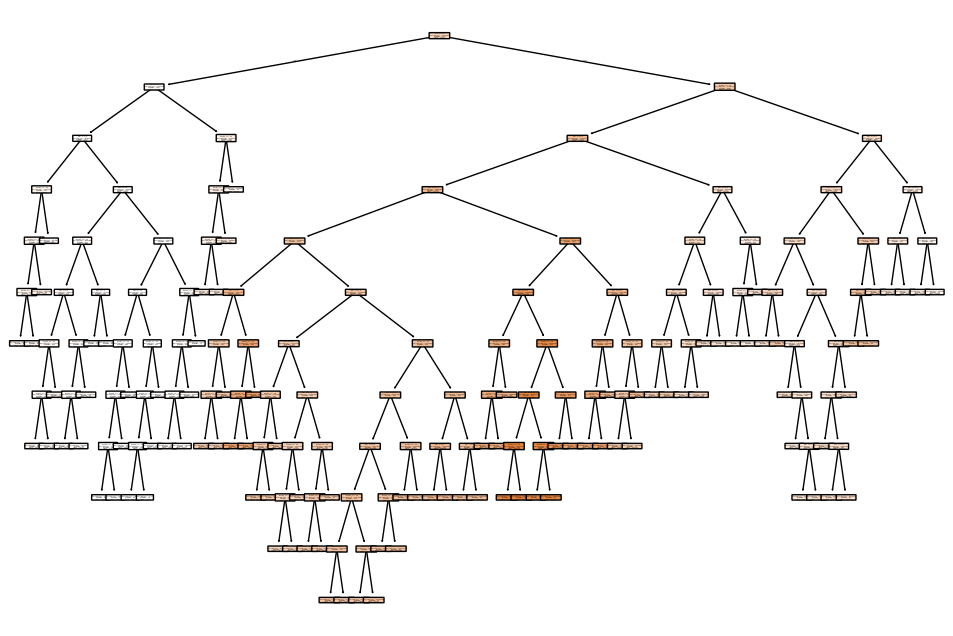

In [38]:
# Visualización del árbol de decisión
plt.figure(figsize=(12, 8))
plot_tree(model_dt, filled=True, feature_names=X.columns, rounded=True)
plt.show()

In [39]:
# Optimización del modelo de árbol de decisión
param_grid = {
    'max_depth': [5, 10, 15, 20, None],           # Diferentes profundidades
    'min_samples_split': [2, 5, 10],              # Diferentes valores para la división
    'min_samples_leaf': [1, 2, 4],                # Diferentes valores para las hojas
    'max_features': ['auto', 'sqrt', 'log2'],     # Diferentes estrategias para las características
    'max_leaf_nodes': [None, 10, 20, 30]          # Diferentes valores para los nodos hoja
}
# Crear el modelo de árbol de decisión
model_dt = DecisionTreeRegressor(random_state=42)

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=model_dt, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Ajustar el modelo
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros
print("Mejores parámetros:", grid_search.best_params_)

# Usar el modelo con los mejores parámetros
best_model = grid_search.best_estimator_

# Realizar las predicciones
y_pred_best = best_model.predict(X_test)

# Evaluar el modelo
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

# Imprimir las métricas de evaluación
print(f'MSE: {mse_best}')
print(f'RMSE: {rmse_best}')
print(f'MAE: {mae_best}')
print(f'R²: {r2_best}')

Mejores parámetros: {'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
MSE: 13777.742696063275
RMSE: 117.37862963956972
MAE: 79.18229973301631
R²: 0.5765944152639564


In [40]:
print ('RMSE modelo lineal', rmse_lr)
print ('RMSE modelo de árbol de decisión', rmse_tdl)
print ('R2 modelo lineal', r2_lr)
print ('R2 modelo de árbol de decisión', r2_tdl)

RMSE modelo lineal 159.97572650003443
RMSE modelo de árbol de decisión 117.37502967481417
R2 modelo lineal 0.2135217904404808
R2 modelo de árbol de decisión 0.5766203862914421


##### Modelos de árbol de decisión
Se evidencia como mejoran considerablemente los parámetros de evaluación del modelo, teniendo: 
- Mejora considerable en el poder predictivo del modelo aumenta 36 % en comparación con el modelo de regresión lineal, lo que lleva a describir adecuadamente cerca del 58% de los datos
- Reducción sensible en el margen de error cuadrático medio, que disminuye de 159 a 117
Si bien es cierto se presentan mejoras considerables en el modelo se sugiere seguir explorando alternativas que permitan optimizarlo y generar mejores resultados.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [41]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [42]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [43]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [44]:
# Celda 6

# Llamado de librerías
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Árbol de Decisión 

arbol = DecisionTreeClassifier(max_depth=5, random_state=1)  # Ejemplo de calibración
arbol.fit(X_train, y_train)

# Predecir y evaluar
y_pred_arbol = arbol.predict(X_test)
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)

print("Árbol de Decisión:")
print(f"Accuracy: {accuracy_arbol:.4f}")
print(f"F1-Score: {f1_arbol:.4f}")

# Regresión Logística

logreg = LogisticRegression(random_state=1, max_iter=1000)  # Aseguramos convergencia
logreg.fit(X_train, y_train)

# Predecir y evaluar
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("\nRegresión Logística:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"F1-Score: {f1_logreg:.4f}")

Árbol de Decisión:
Accuracy: 0.6373
F1-Score: 0.6617

Regresión Logística:
Accuracy: 0.6153
F1-Score: 0.6040


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [45]:
# Celda 7

# Importar librerías necesarias
from sklearn.preprocessing import StandardScaler

# Variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ensamble de 300 modelos
n_models = 100
max_depth_value = 5  # Puedes cambiar este valor
min_samples_leaf_value = 10  # Puedes cambiar este valor

# 100 modelos con max_depth
predictions_tree_depth = []
for _ in range(n_models):
    model = DecisionTreeClassifier(max_depth=max_depth_value, random_state=_)  # Variar la semilla
    model.fit(X_train, y_train)
    predictions_tree_depth.append(model.predict(X_test))

# 100 modelos con min_samples_leaf
predictions_tree_leaf = []
for _ in range(n_models):
    model = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf_value, random_state=_)  # Variar la semilla
    model.fit(X_train, y_train)
    predictions_tree_leaf.append(model.predict(X_test))

# 100 modelos de regresión logística
predictions_log = []
for _ in range(n_models):
    model = LogisticRegression(max_iter=1000, random_state=_)
    model.fit(X_train_scaled, y_train)
    predictions_log.append(model.predict(X_test_scaled))

# Convertir listas a matrices
predictions_tree_depth = np.array(predictions_tree_depth)
predictions_tree_leaf = np.array(predictions_tree_leaf)
predictions_log = np.array(predictions_log)

# Votación mayoritaria
ensemble_predictions = np.concatenate((predictions_tree_depth, predictions_tree_leaf, predictions_log), axis=0)
final_predictions = (ensemble_predictions.sum(axis=0) >= (n_models * 3 / 2)).astype(int)

# Evaluación
accuracy_ensemblevm = accuracy_score(y_test, final_predictions)
f1_ensemblevm = f1_score(y_test, final_predictions)
print(f"Ensamble - Accuracy: {accuracy_ensemblevm:.4f}, F1-Score: {f1_ensemblevm:.4f}")

Ensamble - Accuracy: 0.6280, F1-Score: 0.6372


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [46]:
# Celda 8

# Evaluación Modelo Árbol de Decisión
y_pred_arbol = arbol.predict(X_test)
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)

print("Árbol de Decisión:")
print(f"Accuracy: {accuracy_arbol:.4f}")
print(f"F1-Score: {f1_arbol:.4f}")

# Evaluación Modelo de Regresión Logística
y_pred_logreg = logreg.predict(X_test_scaled)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("\nRegresión Logística:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"F1-Score: {f1_logreg:.4f}")

# Ensamblaje con votación mayoritaria
accuracy_ensemblevm = accuracy_score(y_test, final_predictions)
f1_ensemblevm = f1_score(y_test, final_predictions)

print("\nEnsamblaje con votación mayoritaria:")
print(f"Accuracy: {accuracy_ensemblevm:.4f}")
print(f"F1-Score: {f1_ensemblevm:.4f}")

# Ensamblaje con votación ponderada
weighted_votes = (
    predictions_tree_depth.sum(axis=0) * 1 +
    predictions_tree_leaf.sum(axis=0) * 1 +
    predictions_log.sum(axis=0) * 2
)
total_weighted_models = n_models * (1 + 1 + 2)
final_predictions_weighted = (weighted_votes >= (total_weighted_models / 2)).astype(int)

accuracy_ensemblevp = accuracy_score(y_test, final_predictions_weighted)
f1_ensemblevp = f1_score(y_test, final_predictions_weighted)

print("\nEnsamblaje con votación ponderada:")
print(f"Accuracy: {accuracy_ensemblevp:.4f}")
print(f"F1-Score: {f1_ensemblevp:.4f}")

Árbol de Decisión:
Accuracy: 0.6373
F1-Score: 0.6617

Regresión Logística:
Accuracy: 0.5260
F1-Score: 0.5709

Ensamblaje con votación mayoritaria:
Accuracy: 0.6280
F1-Score: 0.6372

Ensamblaje con votación ponderada:
Accuracy: 0.6307
F1-Score: 0.6524


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

* El modelo que presenta el mejor equilibrio es el modelo de Arbol de decisión (F1-Score de 0.6617), así mismo es el modelo que presenta mejores resultados de Accuracity (Precisión), prediciendo correctamente el 63,73 % de los casos. 
* El siguiente modelo que presenta un muy buen ajuste e interpretabilidad es el modelo de ensamblaje con votación ponderada, del cual se recomienda su uso, teniendo en cuenta que el modelo de árbol de decisión tiene mayor riesgo de presentar over fitting (sobreajuste), al ser muy sensible a pequeñas variaciones en los datos.